# Fama-French Factor Analysis: Emerging vs Developed Market Portfolios

**Research question:** Do emerging market portfolios earn a systematic risk premium over developed markets after controlling for Fama-French factors?

| | |
|---|---|
| **Author** | Diana Krystell Magallanes Pichardo |
| **Course** | Econometría Financiera — EGADE Business School |
| **Data** | Fama-French Data Library, 1989–2025 (monthly) |
| **Tools** | Python · pandas · numpy · scipy · matplotlib · seaborn |

---

## Methodology

Two OLS models are estimated and compared:

**Model 1 — Baseline:**
$$\text{MktRF}_t = \beta_0 + \beta_1 \text{SMB} + \beta_2 \text{HML} + \beta_3 \text{RMW} + \beta_4 \text{CMA} + \beta_5 \text{Emerging} + \varepsilon_t$$

**Model 2 — Extended (heterogeneous factor loadings):**
$$\text{MktRF}_t = \beta_0 + \beta_1 \text{SMB} + \beta_2 \text{HML} + \beta_3 \text{RMW} + \beta_4 \text{CMA} + \beta_5 \text{Emerging} + \beta_6 (\text{Em} \times \text{SMB}) + \beta_7 (\text{Em} \times \text{HML}) + \beta_8 (\text{Em} \times \text{RMW}) + \varepsilon_t$$

The interaction terms allow factor sensitivities to **differ by market type**. The total SMB sensitivity for emerging markets is $\beta_1 + \beta_6$.

## Section 1 — Setup & Data Loading

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from numpy.linalg import lstsq

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
COLORS = {'emerging': '#E63946', 'developed': '#457B9D'}
print('Libraries loaded.')

Libraries loaded.

In [ ]:
# Load raw data
df_raw = pd.read_excel('data/FamaRichvPoor.xlsx')
df_raw = df_raw.rename(columns={'Mkt-RF': 'MktRF'})

# Replace Fama-French missing codes (-99.99, -99.999) with NaN
for col in ['MktRF', 'SMB', 'HML', 'RMW', 'CMA']:
    df_raw[col] = df_raw[col].replace([-99.99, -99.999], np.nan)

# Drop rows with missing values in key variables
df = df_raw.dropna(subset=['MktRF', 'SMB', 'HML', 'RMW', 'CMA', 'Emerging']).copy()
df = df.reset_index(drop=True)

# Date index and derived variables
df['date']    = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2))
df            = df.sort_values('date').reset_index(drop=True)
df['post2000'] = (df['year'] >= 2000).astype(int)
df['Em_SMB']  = df['Emerging'] * df['SMB']
df['Em_HML']  = df['Emerging'] * df['HML']
df['Em_RMW']  = df['Emerging'] * df['RMW']

print(f'Observations: {len(df)}')
print(f"Period: {df['date'].min().strftime('%b %Y')} — {df['date'].max().strftime('%b %Y')}")
print(f"  Emerging  : {df['Emerging'].sum()} obs")
print(f"  Developed : {(df['Emerging']==0).sum()} obs")
df.head(3)

Observations: 826
Period: Jul 1990 — Nov 2025
  Emerging  : 401 obs
  Developed : 425 obs


## Section 2 — Descriptive Statistics

In [ ]:
rows = []
for label, mask in [
    ('Emerging (Full)',       df['Emerging'] == 1),
    ('Developed (Full)',      df['Emerging'] == 0),
    ('Emerging (Post-2000)',  (df['Emerging'] == 1) & (df['post2000'] == 1)),
    ('Developed (Post-2000)', (df['Emerging'] == 0) & (df['post2000'] == 1)),
]:
    sub = df.loc[mask, 'MktRF']
    rows.append({'Portfolio': label, 'N': len(sub),
                 'Mean (%)': round(sub.mean(), 3),
                 'Variance': round(sub.var(), 3),
                 'Std Dev (%)': round(sub.std(), 3),
                 'Skewness': round(sub.skew(), 3),
                 'Kurtosis': round(sub.kurt(), 3)})

stats_df = pd.DataFrame(rows).set_index('Portfolio')
print('Table 1: Descriptive Statistics — Excess Market Returns')
stats_df

Table 1: Descriptive Statistics — Excess Market Returns


## Section 3 — Return Distribution Visualisations

> Emerging markets show heavier tails and wider dispersion in both sample periods,
> consistent with their higher perceived volatility and risk of extreme events.


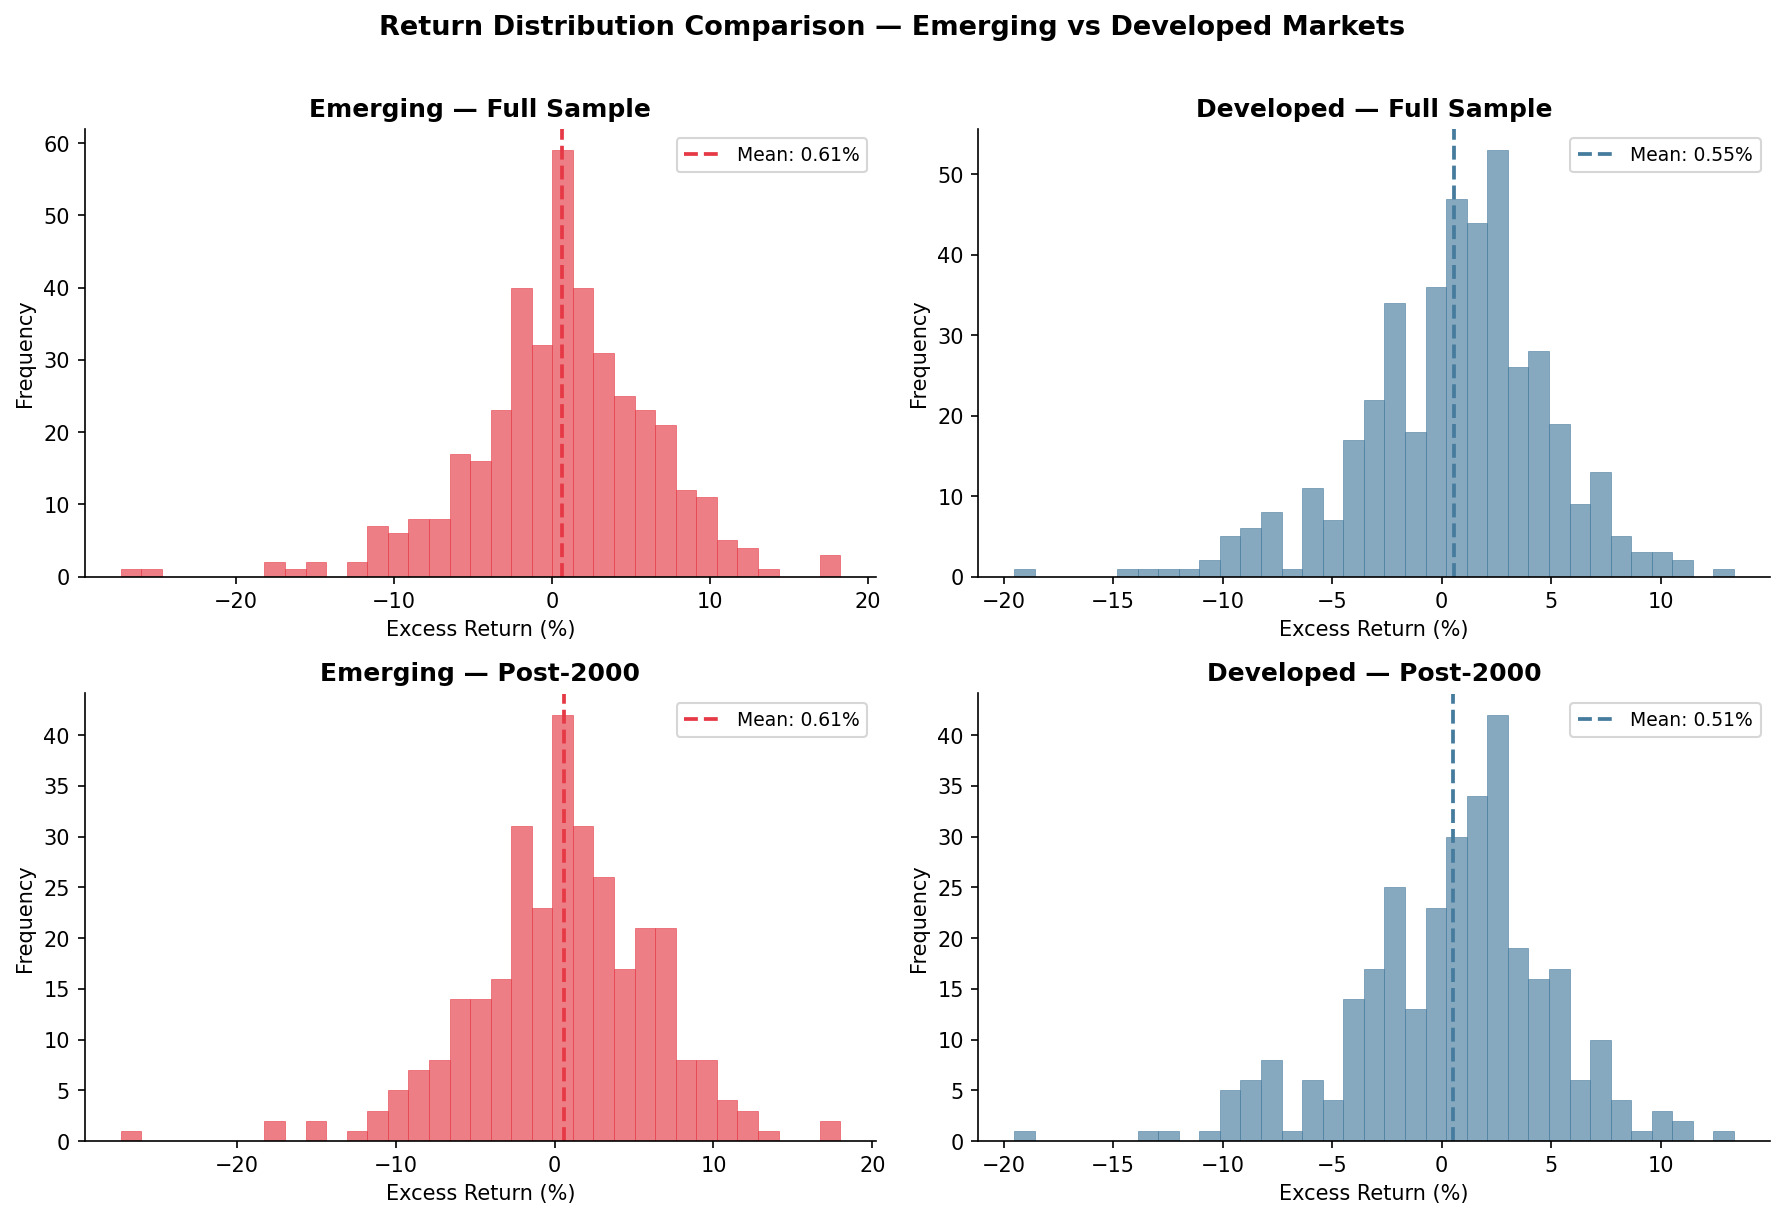

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Return Distribution — Emerging vs Developed Markets', fontsize=13, fontweight='bold')

panels = [
    (0,0, df['Emerging']==1,                           'Emerging — Full Sample',  COLORS['emerging']),
    (0,1, df['Emerging']==0,                           'Developed — Full Sample', COLORS['developed']),
    (1,0, (df['Emerging']==1)&(df['post2000']==1),     'Emerging — Post-2000',    COLORS['emerging']),
    (1,1, (df['Emerging']==0)&(df['post2000']==1),     'Developed — Post-2000',   COLORS['developed']),
]
for r,c,mask,title,color in panels:
    ax = axes[r][c]
    sub = df.loc[mask, 'MktRF']
    ax.hist(sub, bins=35, color=color, alpha=0.65, edgecolor=color, lw=0.4)
    ax.axvline(sub.mean(), color=color, linestyle='--', lw=2,
               label=f'Mean: {sub.mean():.2f}%')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Excess Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

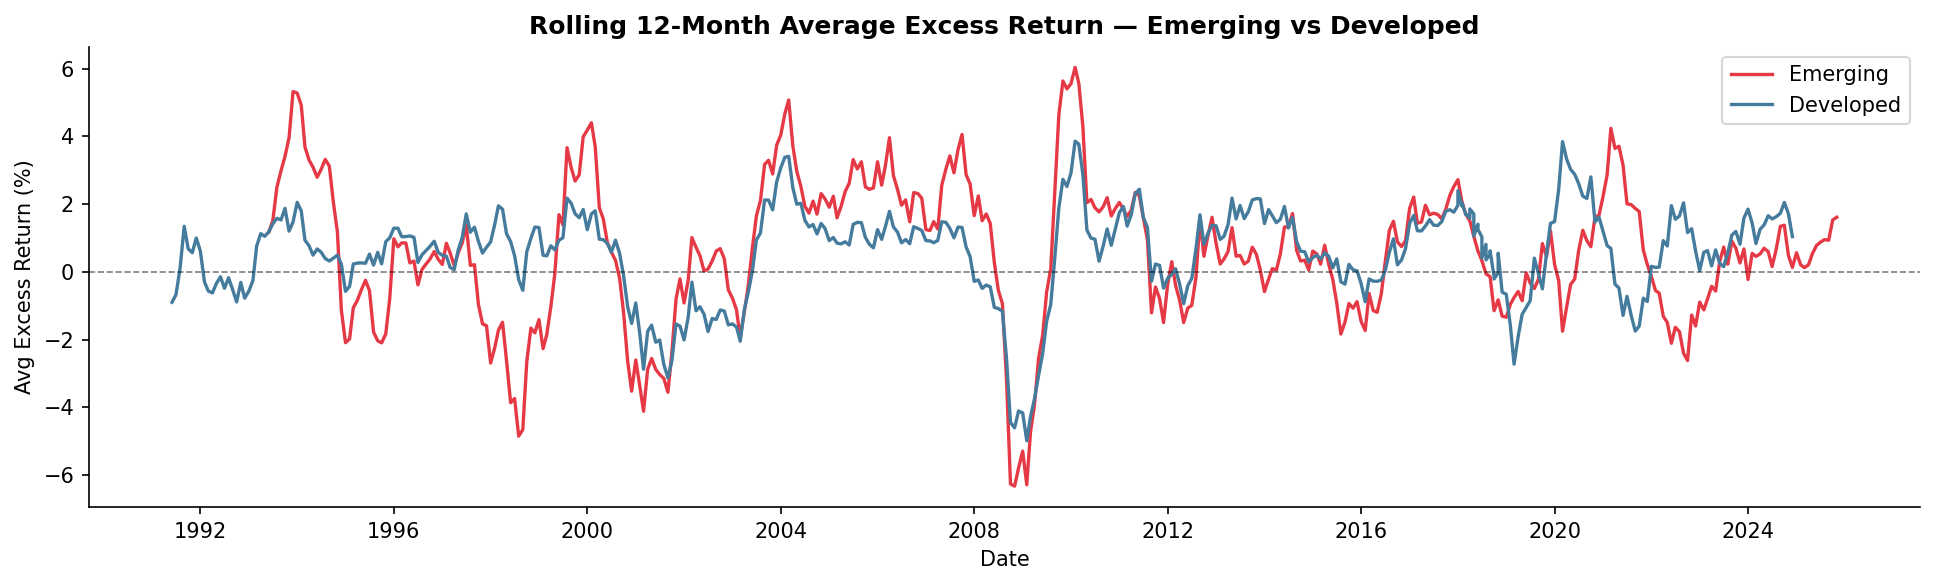

In [ ]:
em  = df[df['Emerging']==1].set_index('date')['MktRF'].rolling(12).mean()
dev = df[df['Emerging']==0].set_index('date')['MktRF'].rolling(12).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(em.index,  em,  color=COLORS['emerging'],  lw=1.8, label='Emerging')
ax.plot(dev.index, dev, color=COLORS['developed'], lw=1.8, label='Developed')
ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title('Rolling 12-Month Average Excess Return — Emerging vs Developed',
             fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Excess Return (%)')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/fig2_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — OLS Regression Engine

A lightweight OLS class using `numpy.linalg.lstsq` — computes coefficients,
standard errors, t-statistics, p-values, R², AIC, and BIC without external dependencies.


In [ ]:
class OLSResult:
    def __init__(self, y, X, names):
        n, k = X.shape
        self.n, self.k, self.names = n, k, names
        self.coef, _, _, _ = lstsq(X, y, rcond=None)
        self.y_hat = X @ self.coef
        self.resid = y - self.y_hat
        self.sigma2 = (self.resid @ self.resid) / (n - k)
        XtX_inv = np.linalg.inv(X.T @ X)
        self.cov = self.sigma2 * XtX_inv
        self.se = np.sqrt(np.diag(self.cov))
        self.t_stat = self.coef / self.se
        self.p_val = 2 * (1 - stats.t.cdf(np.abs(self.t_stat), df=n-k))
        self.ci95 = np.column_stack([self.coef - 1.96*self.se, self.coef + 1.96*self.se])
        ss_tot = np.sum((y - y.mean())**2)
        self.r2 = 1 - (self.resid @ self.resid) / ss_tot
        self.r2_adj = 1 - (1-self.r2)*(n-1)/(n-k)
        log_lik = -n/2 * (1 + np.log(2*np.pi*self.sigma2))
        self.aic = 2*k - 2*log_lik
        self.bic = k*np.log(n) - 2*log_lik

    def summary(self):
        sig = lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
        print(f"{'Variable':<18} {'Coef':>9} {'SE':>9} {'t':>9} {'p':>9}  Sig")
        print('─'*60)
        for i,n in enumerate(self.names):
            print(f"{n:<18} {self.coef[i]:>9.4f} {self.se[i]:>9.4f} "
                  f"{self.t_stat[i]:>9.4f} {self.p_val[i]:>9.4f}  {sig(self.p_val[i])}")
        print('─'*60)
        print(f"N={self.n}  R²={self.r2:.4f}  R²adj={self.r2_adj:.4f}  "
              f"AIC={self.aic:.2f}  BIC={self.bic:.2f}")

print('OLSResult class ready.')

OLSResult class ready.


## Section 5 — Model 1: Baseline

Tests whether a **fixed emerging market premium** exists after controlling for the five Fama-French systematic risk factors.


In [ ]:
y  = df['MktRF'].values
X1 = np.column_stack([np.ones(len(df)), df[['SMB','HML','RMW','CMA','Emerging']].values])
m1 = OLSResult(y, X1, ['const','SMB','HML','RMW','CMA','Emerging'])

print('MODEL 1 — MktRF ~ SMB + HML + RMW + CMA + Emerging')
print('='*60)
m1.summary()

MODEL 1 — MktRF ~ SMB + HML + RMW + CMA + Emerging
Variable            Coef        SE         t         p  Sig
────────────────────────────────────────────────────────────
const             1.0172    0.2204    4.6151    0.0000  ***
SMB              -0.5465    0.0806   -6.7821    0.0000  ***
HML               0.3117    0.0806    3.8678    0.0001  ***
RMW              -1.0462    0.1084   -9.6506    0.0000  ***
CMA              -1.1368    0.1000  -11.3693    0.0000  ***
Emerging         -0.0817    0.3121   -0.2617    0.7936     
────────────────────────────────────────────────────────────
N=826  R²=0.2524  R²adj=0.2479  AIC=4827.27  BIC=4855.57


In [ ]:
# Test 1: H₀: β_Emerging = 0  (is there any emerging premium?)
idx   = m1.names.index('Emerging')
t1    = m1.coef[idx] / m1.se[idx]
p1    = 2 * (1 - stats.t.cdf(abs(t1), df=m1.n - m1.k))
print(f'Test 1 — H₀: β_Emerging = 0')
print(f'  t = {t1:.4f}   p = {p1:.4f}   → {"REJECT" if p1<0.05 else "FAIL TO REJECT"} H₀ (α=0.05)')
print(f'  Interpretation: No significant emerging market premium after FF factor control.')

# Test 2: H₀: β_Emerging = 0.6  (could premium be 0.6%/month?)
t2    = (m1.coef[idx] - 0.6) / m1.se[idx]
p2    = 2 * (1 - stats.t.cdf(abs(t2), df=m1.n - m1.k))
print(f'\nTest 2 — H₀: β_Emerging = 0.6')
print(f'  t = {t2:.4f}   p = {p2:.4f}   → {"REJECT" if p2<0.05 else "FAIL TO REJECT"} H₀ (α=0.05)')
print(f'  Interpretation: Any emerging premium is significantly less than 0.6%/month.')

Test 1 — H₀: β_Emerging = 0
  t = -0.2617   p = 0.7936   → FAIL TO REJECT H₀ (α=0.05)
  Interpretation: No significant emerging market premium after FF factor control.

Test 2 — H₀: β_Emerging = 0.6
  t = -2.1843   p = 0.0292   → REJECT H₀ (α=0.05)
  Interpretation: Any emerging premium is significantly less than 0.6%/month.


## Section 6 — Model 2: Extended with Interaction Terms

Allows the sensitivity to **SMB, HML, and RMW to differ** between emerging and developed markets.
The total SMB sensitivity for emerging markets is $\\beta_1 + \\beta_6$.


In [ ]:
X2 = np.column_stack([
    np.ones(len(df)),
    df[['SMB','HML','RMW','CMA','Emerging','Em_SMB','Em_HML','Em_RMW']].values
])
m2 = OLSResult(y, X2, ['const','SMB','HML','RMW','CMA','Emerging','Em_SMB','Em_HML','Em_RMW'])

print('MODEL 2 — MktRF ~ FF5 + Emerging + Em×SMB + Em×HML + Em×RMW')
print('='*60)
m2.summary()

smb_dev = m2.coef[m2.names.index('SMB')]
smb_em  = smb_dev + m2.coef[m2.names.index('Em_SMB')]
print(f'\nTotal SMB sensitivity — Developed : {smb_dev:.4f}')
print(f'Total SMB sensitivity — Emerging  : {smb_em:.4f}  (β_SMB + β_Em×SMB)')

MODEL 2 — MktRF ~ FF5 + Emerging + Em×SMB + Em×HML + Em×RMW
Variable            Coef        SE         t         p  Sig
────────────────────────────────────────────────────────────
const             0.9584    0.2219    4.3190    0.0000  ***
SMB              -0.3330    0.1179   -2.8246    0.0048  ***
HML               0.3918    0.1009    3.8815    0.0001  ***
RMW              -0.9145    0.1524   -6.0015    0.0000  ***
CMA              -1.1490    0.1011  -11.3694    0.0000  ***
Emerging          0.1565    0.3273    0.4780    0.6328     
Em_SMB           -0.4201    0.1619   -2.5947    0.0096  ***
Em_HML           -0.2632    0.1409   -1.8683    0.0621  *  
Em_RMW           -0.3561    0.2236   -1.5923    0.1117     
────────────────────────────────────────────────────────────
N=826  R²=0.2621  R²adj=0.2548  AIC=4825.60  BIC=4868.05

Total SMB sensitivity — Developed : -0.3330
Total SMB sensitivity — Emerging  : -0.7530  (β_SMB + β_Em×SMB)


In [ ]:
# Test 3: H₀: β_Em×SMB = 0
idx3 = m2.names.index('Em_SMB')
t3   = m2.coef[idx3] / m2.se[idx3]
p3   = 2 * (1 - stats.t.cdf(abs(t3), df=m2.n - m2.k))
print(f'Test 3 — H₀: β_Em×SMB = 0')
print(f'  t = {t3:.4f}   p = {p3:.4f}   → {"REJECT" if p3<0.05 else "FAIL TO REJECT"} H₀ (α=0.05)')

# Test 4: Joint F-test  H₀: β_Em×HML = β_Em×RMW = 0
idx4 = [m2.names.index('Em_HML'), m2.names.index('Em_RMW')]
R    = np.zeros((2, m2.k)); R[0, idx4[0]] = 1; R[1, idx4[1]] = 1
Rb   = R @ m2.coef
F4   = (Rb @ np.linalg.inv(R @ m2.cov @ R.T) @ Rb) / 2
p4   = 1 - stats.f.cdf(F4, 2, m2.n - m2.k)
print(f'\nTest 4 — Joint F: H₀: β_Em×HML = β_Em×RMW = 0')
print(f'  F = {F4:.4f}   p = {p4:.4f}   → {"REJECT" if p4<0.05 else "FAIL TO REJECT"} H₀ (α=0.05)')

Test 3 — H₀: β_Em×SMB = 0
  t = -2.5947   p = 0.0096   → REJECT H₀ (α=0.05)

Test 4 — Joint F: H₀: β_Em×HML = β_Em×RMW = 0
  F = 2.3664   p = 0.0945   → FAIL TO REJECT H₀ (α=0.05)


## Section 7 — Model Comparison & Selection

AIC is preferred for **economic inference** goals (identifying heterogeneous effects). 
BIC is more conservative and penalises complexity more heavily for large samples.


In [ ]:
comp = pd.DataFrame({
    'Model 1': [m1.aic, m1.bic, m1.r2, m1.r2_adj, m1.k],
    'Model 2': [m2.aic, m2.bic, m2.r2, m2.r2_adj, m2.k],
}, index=['AIC','BIC','R²','R² Adjusted','Parameters'])
comp['Δ (M2−M1)'] = comp['Model 2'] - comp['Model 1']
print('Model Comparison Table')
print(comp.round(4).to_string())
print('\n→ Preferred: Model 2 (lower AIC; Em×SMB significant at p=0.010)')

Model Comparison Table
               Model 1    Model 2  Δ (M2−M1)
AIC          4827.2658  4825.5985    -1.6673
BIC          4855.5654  4868.0478    12.4825
R²              0.2524     0.2621     0.0096
R² Adjusted     0.2479     0.2548     0.0069
Parameters      6.0000     9.0000     3.0000

→ Preferred: Model 2 (lower AIC; Em×SMB significant at p=0.010)


## Section 8 — Coefficient Forest Plot

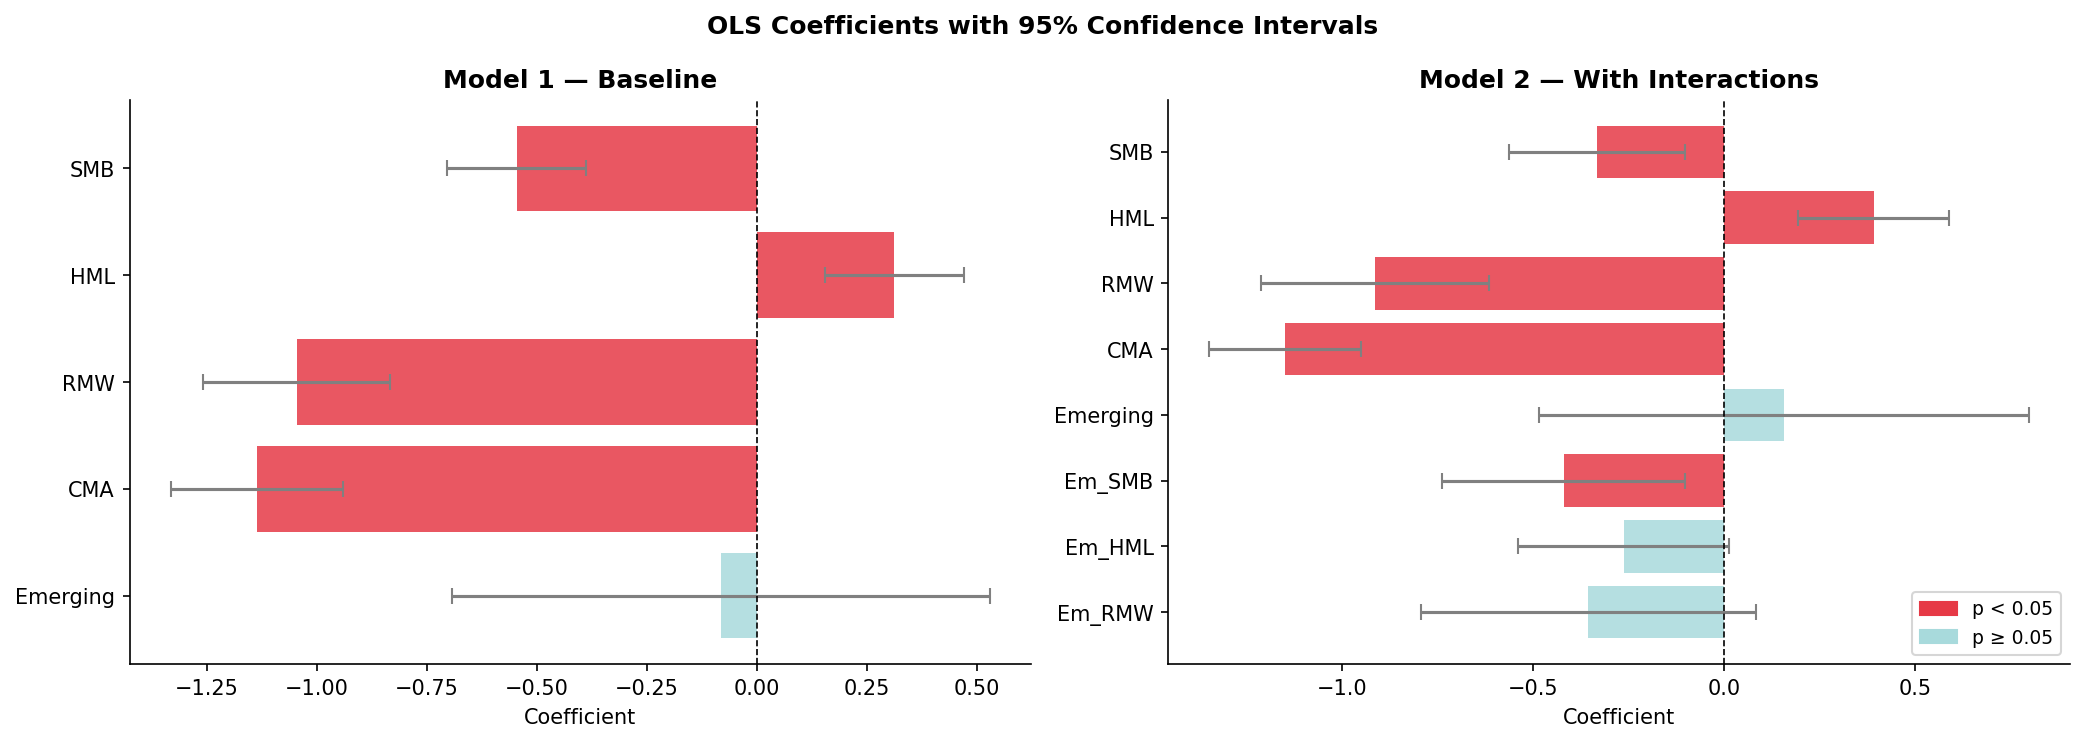

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in zip(axes,
        [m1, m2], ['Model 1 — Baseline', 'Model 2 — With Interactions']):
    names  = [n for n in model.names if n != 'const']
    idx    = [model.names.index(n) for n in names]
    coefs  = model.coef[idx]
    cis    = model.ci95[idx]
    yerrs  = np.abs(cis - coefs[:, None]).T
    colors_bar = ['#E63946' if p < 0.05 else '#A8DADC' for p in model.p_val[idx]]
    ax.barh(names, coefs, xerr=yerrs, color=colors_bar,
            align='center', alpha=0.85, capsize=4,
            error_kw={'elinewidth':1.5, 'ecolor':'gray'})
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Coefficient')
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#E63946', label='p < 0.05'),
                         Patch(color='#A8DADC', label='p ≥ 0.05')],
               loc='lower right', fontsize=9)
plt.suptitle('OLS Coefficients with 95% Confidence Intervals', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig3_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Key Findings & Economic Interpretation

| Finding | Evidence |
|---------|----------|
| **No country-risk premium** | β_Emerging insignificant in both models (p=0.794, p=0.633) |
| **Higher volatility, marginal return gain** | Emerging σ = 5.88% vs Developed σ = 4.35% monthly; return diff = +0.06% |
| **Structural size-factor difference** | Em×SMB significant (β=−0.42, p=0.010); total SMB emerging = −0.753 vs −0.333 |
| **Preferred model** | Model 2 — lower AIC (4825.60 vs 4827.27); heterogeneous loadings justified |

**Investment implication for Mexican investors:**  
A Mexican investor already has emerging market exposure via the domestic market.  
Diversifying toward **developed markets** may offer similar expected returns  
with significantly lower volatility and tail risk.

---

## References
- Fama, E. F., & French, K. R. (1993). *Common risk factors in the returns on stocks and bonds.* Journal of Financial Economics, 33(1), 3–56.
- Fama, E. F., & French, K. R. (2015). *A five-factor asset pricing model.* Journal of Financial Economics, 116(1), 1–22.
- Harvey, C. R. (1995). *Predictable risk and returns in emerging markets.* Review of Financial Studies, 8(3), 773–816.
